# Logistic Regression - IT22253644

individual contribution: cancellation prediction using Logistic Regression.

Dataset = hotel_booking.csv

## Dataset Description
- Source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
- Size: 119,390 rows, 32 columns
- Context: Hotel booking records from a city hotel and resort hotel
- Target: is_canceled (1 = cancelled, 0 = not cancelled)

Key columns:
- lead_time: Days between booking and arrival
- deposit_type: Type of deposit made
- previous_cancellations: Past cancellations by the customer
- country: Country of origin of the guest

## Algorithm Introduction - Logistic Regression
Logistic Regression is a supervised learning algorithm used for binary 
classification. It models the probability that an input belongs to a class 
using the sigmoid function. It is chosen here because:
- The target (is_canceled) is binary (0 or 1)
- It is interpretable — coefficients show feature impact
- It works well on large tabular datasets

In [1]:
# Cell 1 - Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score, f1_score
 )
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Cell 2 - Load dataset
df = pd.read_csv('hotel_bookings.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (119390, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


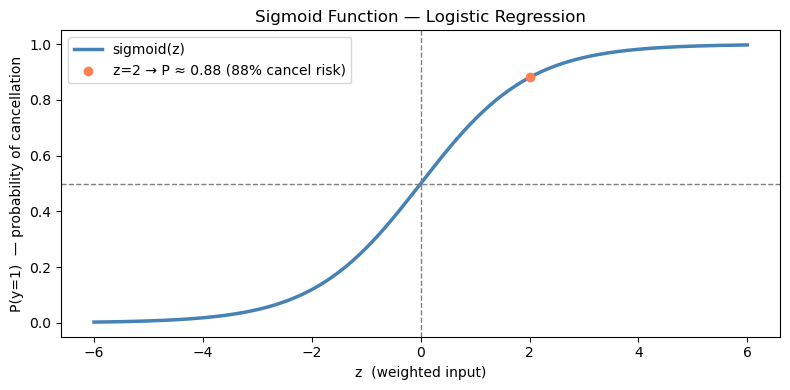

In [3]:
# Sigmoid Function Visualization - 
z = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, color='steelblue', linewidth=2.5, label='sigmoid(z)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0,   color='gray', linestyle='--', linewidth=1)
plt.scatter([2], [1 / (1 + np.exp(-2))], color='coral', zorder=5,
            label='z=2 → P ≈ 0.88 (88% cancel risk)')
plt.xlabel('z  (weighted input)')
plt.ylabel('P(y=1)  — probability of cancellation')
plt.title('Sigmoid Function — Logistic Regression')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Statistical summary
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
# Cell 3 - Quick overview
print('Column names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nigh

In [6]:
# Cell 4 - Check missing values (imputation will be done inside the pipeline)
print('Missing values before modeling:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\nTotal missing values:', df.isnull().sum().sum())

Missing values before modeling:
children         4
country        488
agent        16340
company     112593
dtype: int64

Total missing values: 129425


In [7]:
# Cell 5 - Drop leakage and non-direct date column
df = df.drop(['reservation_status', 'reservation_status_date'], axis=1)

print('Remaining columns:', df.shape[1])

Remaining columns: 30


In [8]:
# Cell 6 - Identify categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').drop('is_canceled', axis=1).columns.tolist()

print('Categorical columns:', len(cat_cols))
print('Numerical columns:', len(num_cols))
print('Sample categorical columns:', cat_cols[:8])

Categorical columns: 10
Numerical columns: 19
Sample categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type']


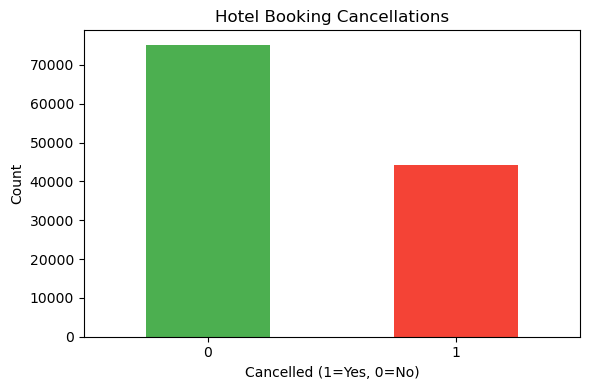

Cancellation rate: 37.04 %


In [9]:
# Cell 7 - Target variable distribution
plt.figure(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'])
plt.title('Hotel Booking Cancellations')
plt.xlabel('Cancelled (1=Yes, 0=No)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Cancellation rate:', round(df['is_canceled'].mean() * 100, 2), '%')

Top features correlated with cancellation:
is_canceled                 1.000000
lead_time                   0.293123
previous_cancellations      0.110133
adults                      0.060017
days_in_waiting_list        0.054186
adr                         0.047557
stays_in_week_nights        0.024765
arrival_date_year           0.016660
arrival_date_week_number    0.008148
children                    0.005048
Name: is_canceled, dtype: float64


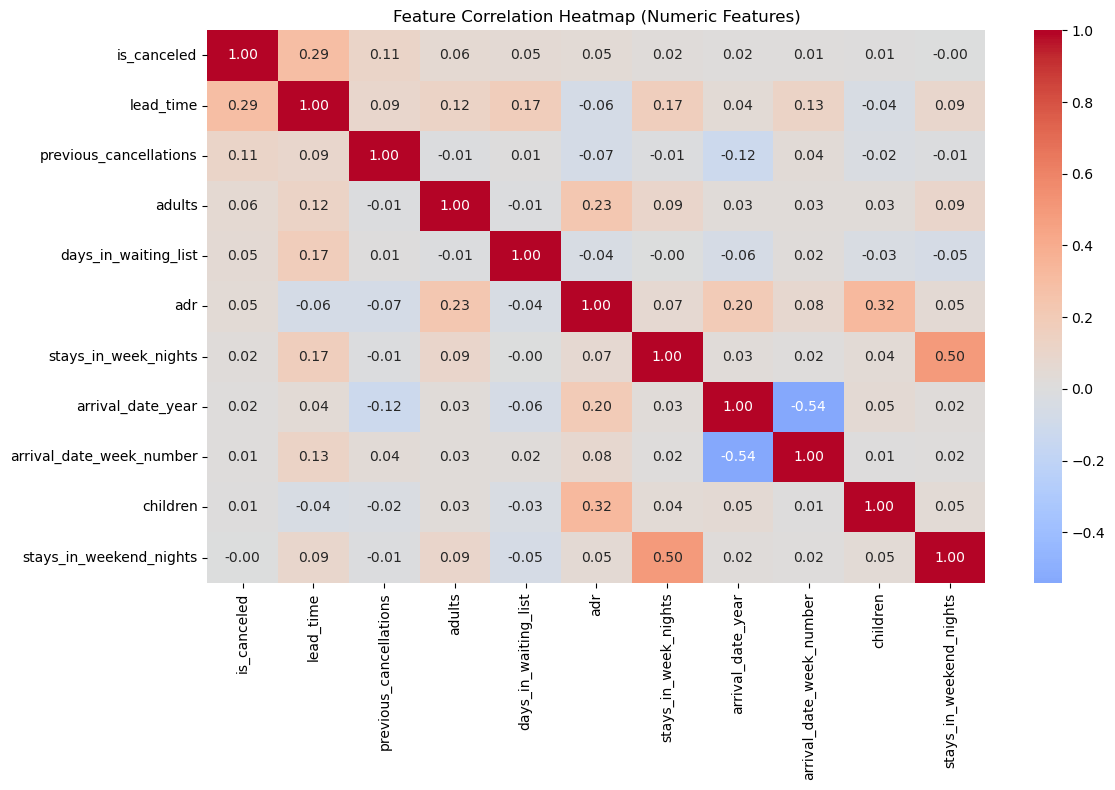

In [10]:
# Cell 8 - Correlation heatmap (top numeric features)
plt.figure(figsize=(12, 8))
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()['is_canceled'].sort_values(ascending=False)
print('Top features correlated with cancellation:')
print(corr.head(10))

sns.heatmap(num_df[corr.head(11).index].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

In [11]:
# Cell 9 - Define features (X) and target (y)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

print('Features shape:', X.shape)
print('Target distribution:\n', y.value_counts())

Features shape: (119390, 29)
Target distribution:
 is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [12]:
# Cell 10 - Split into train/validation/test sets
from sklearn.model_selection import train_test_split

required_vars = ['X', 'y']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print('Cannot split data yet.')
    print('Missing variables:', ', '.join(missing_vars))
    print('Run Cells 1 to 9 first, then run this cell.')
else:
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Use a validation split from training data for threshold tuning
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )

    print('Training set size:', X_train.shape[0])
    print('Validation set size:', X_val.shape[0])
    print('Test set size:', X_test.shape[0])

Training set size: 76409
Validation set size: 19103
Test set size: 23878


In [13]:
# Cell 11 - Build preprocessing pipeline (leakage-safe)
num_cols2 = X_train.select_dtypes(exclude='object').columns.tolist()
cat_cols2 = X_train.select_dtypes(include='object').columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess2 = ColumnTransformer([
    ('num', num_pipe, num_cols2),
    ('cat', cat_pipe, cat_cols2)
])

print('Preprocessing pipeline ready!')
print('Numeric features:', len(num_cols2))
print('Categorical features:', len(cat_cols2))

Preprocessing pipeline ready!
Numeric features: 19
Categorical features: 10


In [14]:
# Cell 12a - Train BASELINE Logistic Regression (default hyperparameters, no tuning)
# Baseline uses default C=1.0, no class_weight, default solver=lbfgs
from sklearn.metrics import precision_score, recall_score

baseline_pipe = Pipeline([
    ('preprocess', preprocess2),
    ('model', LogisticRegression(
        C=1.0,
        penalty='l2',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

baseline_pipe.fit(X_train, y_train)

# Evaluate baseline on test set (using default threshold 0.5)
baseline_pred = baseline_pipe.predict(X_test)
baseline_prob = baseline_pipe.predict_proba(X_test)[:, 1]

baseline_accuracy  = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall    = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1        = f1_score(y_test, baseline_pred, zero_division=0)
baseline_roc_auc   = roc_auc_score(y_test, baseline_prob)

print('=== Baseline Logistic Regression (C=1.0, threshold=0.5, no class_weight) ===')
print(f'Accuracy : {baseline_accuracy * 100:.2f}%')
print(f'Precision: {baseline_precision:.4f}')
print(f'Recall   : {baseline_recall:.4f}')
print(f'F1-Score : {baseline_f1:.4f}')
print(f'ROC-AUC  : {baseline_roc_auc:.4f}')


=== Baseline Logistic Regression (C=1.0, threshold=0.5, no class_weight) ===
Accuracy : 82.01%
Precision: 0.8152
Recall   : 0.6651
F1-Score : 0.7325
ROC-AUC  : 0.8961


In [15]:
# Cell 12 - Train tuned Logistic Regression with cross-validation
tuned_pipe = Pipeline([
    ('preprocess', preprocess2),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

# Leaner grid for faster execution on large one-hot encoded data
param_grid = {
    'model__solver': ['lbfgs'],
    'model__penalty': ['l2'],
    'model__C': [0.3, 1.0, 3.0, 10.0],
    'model__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=tuned_pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
 )

grid.fit(X_train, y_train)
best_lr = grid.best_estimator_

print('Model trained successfully with tuning!')
print('Best params:', grid.best_params_)
print('Best CV ROC-AUC:', round(grid.best_score_, 4))

Model trained successfully with tuning!
Best params: {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.8983


In [16]:
# Cell 13 - Threshold tuning on validation set, final metrics on test set
y_val_prob = best_lr.predict_proba(X_val)[:, 1]

threshold_grid = np.arange(0.30, 0.71, 0.01)
rows = []

for th in threshold_grid:
    y_val_pred_th = (y_val_prob >= th).astype(int)
    rows.append({
        'threshold': th,
        'f1': f1_score(y_val, y_val_pred_th),
        'accuracy': accuracy_score(y_val, y_val_pred_th)
    })

th_df = pd.DataFrame(rows)
best_row = th_df.loc[th_df['f1'].idxmax()]
best_threshold = float(best_row['threshold'])

# Evaluate once on the untouched test set
y_prob = best_lr.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f'Best Threshold (from validation by F1): {best_threshold:.2f}')
print(f'Accuracy:  {accuracy * 100:.2f}%')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred,
      target_names=['Not Cancelled', 'Cancelled']))

Best Threshold (from validation by F1): 0.48
Accuracy:  80.71%
ROC-AUC:   0.8963
PR-AUC:    0.8546

Detailed Report:
               precision    recall  f1-score   support

Not Cancelled       0.87      0.81      0.84     15033
    Cancelled       0.71      0.80      0.75      8845

     accuracy                           0.81     23878
    macro avg       0.79      0.81      0.80     23878
 weighted avg       0.81      0.81      0.81     23878



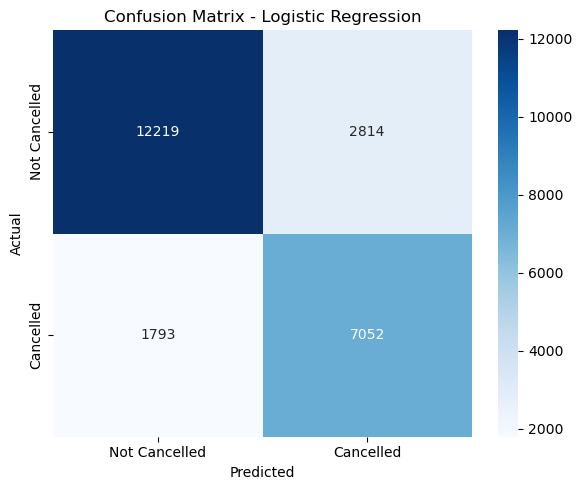

In [17]:
# Cell 14 - Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

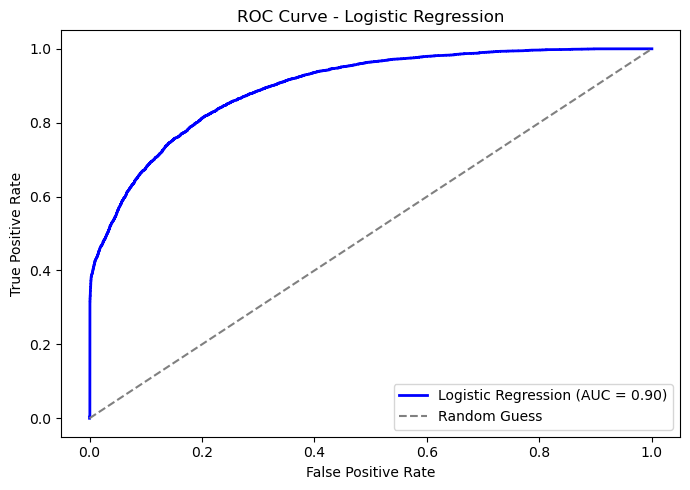

In [18]:
# Cell 15 - ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

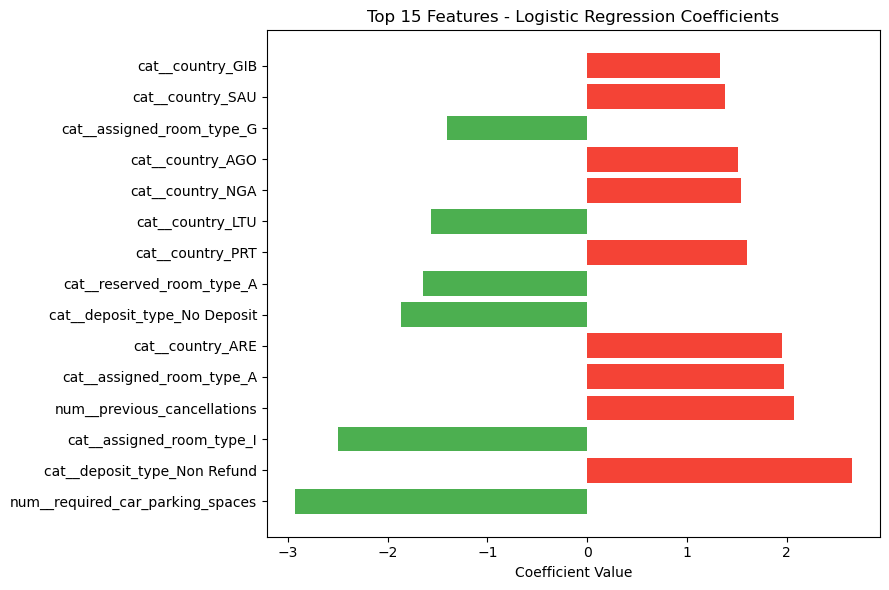

                         Feature  Coefficient
num__required_car_parking_spaces    -2.931718
    cat__deposit_type_Non Refund     2.657527
       cat__assigned_room_type_I    -2.493240
     num__previous_cancellations     2.072351
       cat__assigned_room_type_A     1.973885
                cat__country_ARE     1.957146
    cat__deposit_type_No Deposit    -1.864176
       cat__reserved_room_type_A    -1.646122
                cat__country_PRT     1.607337
                cat__country_LTU    -1.569533


In [19]:
# Cell 16 - Feature importance (top coefficients)
feature_names = best_lr.named_steps['preprocess'].get_feature_names_out()
coefficients = best_lr.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(9, 6))
colors = ['#F44336' if c > 0 else '#4CAF50' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.title('Top 15 Features - Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(coef_df.head(10).to_string(index=False))

In [20]:
# Cell 17 - Overfitting analysis (train vs test accuracy)
required_vars = ['best_lr', 'X_train', 'X_test', 'y_train', 'y_test']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print('Cannot run overfitting analysis yet.')
    print('Missing variables:', ', '.join(missing_vars))
    print('Run Cells 1 to 16 first, then run this cell.')
else:
    y_train_pred = best_lr.predict(X_train)
    y_test_pred = best_lr.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    accuracy_gap = train_accuracy - test_accuracy

    print(f'Training Accuracy: {train_accuracy * 100:.2f}%')
    print(f'Test Accuracy:     {test_accuracy * 100:.2f}%')
    print(f'Accuracy Gap:      {accuracy_gap * 100:.2f}%')

    if accuracy_gap > 0.05:
        print('Potential overfitting detected (gap > 5%).')
    else:
        print('No strong overfitting signal (gap <= 5%).')

Training Accuracy: 81.33%
Test Accuracy:     80.95%
Accuracy Gap:      0.37%
No strong overfitting signal (gap <= 5%).


## Critical Analysis and Discussion
1. Logistic Regression assumes a linear relationship between features and log-odds, so complex non-linear booking patterns may be missed.
2. Class imbalance can bias predictions; this can be improved using SMOTE or class balancing strategies.
3. Future work can include polynomial/interaction features and model comparison with Random Forest.
4. For Sri Lankan hotels, adding seasonal/time-based features (peak months and holiday windows) can improve practical forecasting.
5. Positive coefficients increase cancellation probability, while negative coefficients reduce cancellation probability.